<a href="https://colab.research.google.com/github/Dhirajj07/Factory-Reallocation-Shipping-Optimization-Recommendation-System-for-Nassau-Candy-Distributor/blob/main/Factory_Reallocation_%26_Shipping_Optimization_Recommendation_System_for_Nassau_Candy_Distributor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Cleaning and Validation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=b3bf36907442f024c45a5f1d6f2d2f8b1b183c94652d6055d9d37dce24f94840
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [ ]:
from apyori import apriori

In [ ]:
df = pd.read_csv('/content/Nassau Candy Distributor.csv')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True, errors='coerce')

In [ ]:
df = df.dropna(subset=['Order Date'])
df['Order Date']

,Order Date
0,2024-03-01
1,2024-04-01
2,2024-04-01
3,2024-04-01
4,2024-05-01
...,...
9956,2025-11-12
9957,2025-11-12
9958,2025-11-12
9959,2025-11-12


In [ ]:
df['Order Date'].isna().sum()


np.int64(0)

**During date validation, 6064 records in the Order Date column were found to be invalid and were converted to NaT during datetime parsing. Since lead time and time-based analysis depend on this field, these records were removed from the dataset to maintain data accuracy.**


In [ ]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], infer_datetime_format=True, errors='coerce')


In [ ]:
df['Ship Date'].isna().sum()

np.int64(0)

In [ ]:
df['Ship Date']

,Ship Date
0,2026-06-30
1,2026-07-01
2,2026-07-01
3,2026-07-01
4,2026-07-05
...,...
9956,2030-06-04
9957,2030-06-07
9958,2030-06-10
9959,2030-06-09


**Date formats were validated by converting the Ship Date column to datetime format. No invalid dates were found.**

In [ ]:
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df = df[df['Shipping Lead Time'] >= 0]
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,821
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,821
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,821
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9956,9957,US-2024-149706-CHO-MIL-31000,2025-11-12,2030-06-04,First Class,149706,United States,Palatine,Illinois,60067,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,22.75,7,14.77,7.98,1665
9957,9958,US-2024-101798-CHO-NUT-13000,2025-11-12,2030-06-07,Standard Class,101798,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,1668
9958,9959,US-2024-129581-CHO-MIL-31000,2025-11-12,2030-06-10,Standard Class,129581,United States,New Bedford,Massachusetts,2740,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,1671
9959,9960,US-2024-168389-CHO-NUT-13000,2025-11-12,2030-06-09,Standard Class,168389,United States,Jacksonville,Florida,32216,Chocolate,Gulf,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,13.96,4,9.96,4.00,1670


In [ ]:
(df['Shipping Lead Time']<0).sum()

np.int64(0)

In [ ]:
df['Ship Mode'].isna().sum()

np.int64(0)

**After checking the shipment-related columns such as Ship Mode and Ship Date, no missing values were found. Therefore, no imputation or deletion was required for shipment records.**

In [ ]:
df['City'] = df['City'].str.strip().str.title()
df['State/Province'] = df['State/Province'].str.strip().str.upper()


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,TEXAS,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,821
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,821
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,821
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,PENNSYLVANIA,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,795


**Geographic fields were standardized by converting state names to uppercase and removing extra spaces.**

# **Feature Engineering**

In [ ]:
# Extract time-based features from 'Order Date'
df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Day'] = df['Order Date'].dt.day
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek

# Extract time-based features from 'Ship Date'
df['Ship_Year'] = df['Ship Date'].dt.year
df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Day'] = df['Ship Date'].dt.day
df['Ship_DayOfWeek'] = df['Ship Date'].dt.dayofweek

# Display the new columns
display(df[['Order Date', 'Order_Year', 'Order_Month', 'Order_Day', 'Order_DayOfWeek',
          'Ship Date', 'Ship_Year', 'Ship_Month', 'Ship_Day', 'Ship_DayOfWeek']].head())

,Order Date,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship Date,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek
0,2024-03-01,2024,3,1,4,2026-06-30,2026,6,30,1
1,2024-04-01,2024,4,1,0,2026-07-01,2026,7,1,2
2,2024-04-01,2024,4,1,0,2026-07-01,2026,7,1,2
3,2024-04-01,2024,4,1,0,2026-07-01,2026,7,1,2
4,2024-05-01,2024,5,1,2,2026-07-05,2026,7,5,6


In [ ]:
df['Product Name'].unique()

array(['Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
       'Wonka Bar - Nutty Crunch Surprise',
       'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Fudge Mallows',
       'Wonka Gum', 'Kazookles', 'Lickable Wallpaper', 'Nerds',
       'SweeTARTS', 'Everlasting Gobstopper', 'Hair Toffee', 'Fun Dip',
       'Laffy Taffy', 'Fizzy Lifting Drinks'], dtype=object)

In [ ]:
factory_map = {
    "Wonka Bar - Nutty Crunch Surprise" : "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows" : "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious" : "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate" : "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel" : "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS" : "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip" : "Sugar Shack",
    "Fizzy Lifting Drinks" : "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum" : "Secret Factory",
    "Kazookles" : "The Other Factory",
    "Hair Toffee": "The Other Factory" }


df["Factory"] = df["Product Name"].map(factory_map)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Shipping Lead Time,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek,Factory
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,TEXAS,77095,...,851,2024,3,1,4,2026,6,30,1,Wicked Choccy's
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,821,2024,4,1,0,2026,7,1,2,Wicked Choccy's
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,821,2024,4,1,0,2026,7,1,2,Lot's O' Nuts
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,821,2024,4,1,0,2026,7,1,2,Lot's O' Nuts
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,PENNSYLVANIA,19143,...,795,2024,5,1,2,2026,7,5,6,Wicked Choccy's


In [ ]:
df['Factory to Customer Region'] = df['Factory'] + " → " + df['Country/Region']
display(df[['Factory', 'Country/Region', 'Factory to Customer Region']].head())

,Factory,Country/Region,Factory to Customer Region
0,Wicked Choccy's,United States,Wicked Choccy's → United States
1,Wicked Choccy's,United States,Wicked Choccy's → United States
2,Lot's O' Nuts,United States,Lot's O' Nuts → United States
3,Lot's O' Nuts,United States,Lot's O' Nuts → United States
4,Wicked Choccy's,United States,Wicked Choccy's → United States


In [ ]:
df['Factory to Customer State'] = df['Factory'] + " → " + df['State/Province']
display(df[['Factory', 'State/Province', 'Factory to Customer State']].head())

,Factory,State/Province,Factory to Customer State
0,Wicked Choccy's,TEXAS,Wicked Choccy's → TEXAS
1,Wicked Choccy's,ILLINOIS,Wicked Choccy's → ILLINOIS
2,Lot's O' Nuts,ILLINOIS,Lot's O' Nuts → ILLINOIS
3,Lot's O' Nuts,ILLINOIS,Lot's O' Nuts → ILLINOIS
4,Wicked Choccy's,PENNSYLVANIA,Wicked Choccy's → PENNSYLVANIA


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,Ship_Month,Ship_Day,Ship_DayOfWeek,Factory,Factory to Customer Region,Factory to Customer State
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,TEXAS,77095,...,3,1,4,2026,6,30,1,Wicked Choccy's,Wicked Choccy's → United States,Wicked Choccy's → TEXAS
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,4,1,0,2026,7,1,2,Wicked Choccy's,Wicked Choccy's → United States,Wicked Choccy's → ILLINOIS
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,4,1,0,2026,7,1,2,Lot's O' Nuts,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,ILLINOIS,60540,...,4,1,0,2026,7,1,2,Lot's O' Nuts,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,PENNSYLVANIA,19143,...,5,1,2,2026,7,5,6,Wicked Choccy's,Wicked Choccy's → United States,Wicked Choccy's → PENNSYLVANIA


# **Data Preparation & Encoding**

### Normalize Numerical Features

In [ ]:
# Identify numerical features to normalize (excluding Row ID, Customer ID, and time-based features)
numerical_cols = ['Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Lead Time']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

display(df_scaled[numerical_cols].head())

,Sales,Units,Gross Profit,Cost,Shipping Lead Time
0,-0.654143,-0.807968,-0.748396,-0.483568,-1.700862
1,-0.564745,-0.807968,-0.644839,-0.419170,-1.799940
2,-0.299232,-0.351795,-0.253451,-0.338674,-1.799940
3,-0.269730,-0.351795,-0.248882,-0.278301,-1.799940
4,-0.229501,-0.351795,-0.271726,-0.157556,-1.885807


### Encode Categorical Variables

In [ ]:
# Identify categorical features to encode
categorical_cols = ['Region', 'Ship Mode']

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(df_scaled[categorical_cols])

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols), index=df_scaled.index)

# Concatenate the encoded DataFrame with the scaled DataFrame
df_encoded = pd.concat([df_scaled.drop(columns=categorical_cols), encoded_df], axis=1)

display(df_encoded.head())

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Country/Region,City,State/Province,Postal Code,Division,...,Factory to Customer Region,Factory to Customer State,Region_Atlantic,Region_Gulf,Region_Interior,Region_Pacific,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,103800,United States,Houston,TEXAS,77095,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → TEXAS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,141817,United States,Philadelphia,PENNSYLVANIA,19143,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → PENNSYLVANIA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Remove Extreme Outliers from 'Sales'

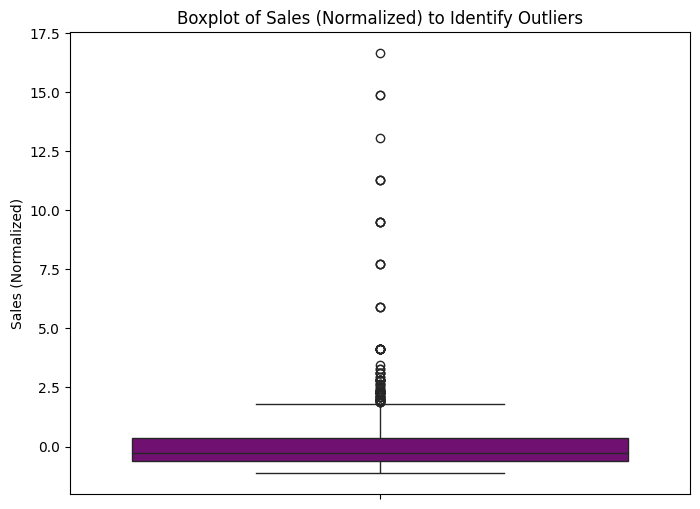


Original DataFrame shape: (4130, 36)
DataFrame shape after outlier removal: (4031, 36)


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_encoded['Sales'],color='purple')
plt.title('Boxplot of Sales (Normalized) to Identify Outliers')
plt.ylabel('Sales (Normalized)')
plt.show()

# Calculate IQR for 'Sales' (already normalized in df_encoded)
Q1 = df_encoded['Sales'].quantile(0.25)
Q3 = df_encoded['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df_encoded[(df_encoded['Sales'] >= lower_bound) & (df_encoded['Sales'] <= upper_bound)]

print("")
print(f"Original DataFrame shape: {df_encoded.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")


In [ ]:
display(df_no_outliers)

,Row ID,Order ID,Order Date,Ship Date,Customer ID,Country/Region,City,State/Province,Postal Code,Division,...,Factory to Customer Region,Factory to Customer State,Region_Atlantic,Region_Gulf,Region_Interior,Region_Pacific,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,103800,United States,Houston,TEXAS,77095,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → TEXAS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,112326,United States,Naperville,ILLINOIS,60540,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → ILLINOIS,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,141817,United States,Philadelphia,PENNSYLVANIA,19143,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → PENNSYLVANIA,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9956,9957,US-2024-149706-CHO-MIL-31000,2025-11-12,2030-06-04,149706,United States,Palatine,ILLINOIS,60067,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → ILLINOIS,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9957,9958,US-2024-101798-CHO-NUT-13000,2025-11-12,2030-06-07,101798,United States,New York City,NEW YORK,10009,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → NEW YORK,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9958,9959,US-2024-129581-CHO-MIL-31000,2025-11-12,2030-06-10,129581,United States,New Bedford,MASSACHUSETTS,2740,Chocolate,...,Wicked Choccy's → United States,Wicked Choccy's → MASSACHUSETTS,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9959,9960,US-2024-168389-CHO-NUT-13000,2025-11-12,2030-06-09,168389,United States,Jacksonville,FLORIDA,32216,Chocolate,...,Lot's O' Nuts → United States,Lot's O' Nuts → FLORIDA,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### Create Training-Ready Feature Matrix

In [ ]:
# Drop non-feature columns (e.g., IDs, original date columns, Product Name, Division, City, State/Province, Postal Code, Factory)
# We keep the extracted date features (Order_Year, Order_Month, etc.) if they are intended for the model.

columns_to_drop_from_features = [
    'Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer ID',
    'Country/Region', 'Product ID', 'Product Name', 'Division', 'City',
    'State/Province', 'Postal Code', 'Factory', 'Factory to Customer Region', 'Factory to Customer State'
]

# Ensure only existing columns are dropped
final_feature_matrix = df_no_outliers.drop(columns=[col for col in columns_to_drop_from_features if col in df_no_outliers.columns], errors='ignore')

print("Shape of the final training-ready feature matrix:", final_feature_matrix.shape,"\n")
display(final_feature_matrix.head())

Shape of the final training-ready feature matrix: (4031, 21) 



,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Ship_Year,...,Ship_Day,Ship_DayOfWeek,Region_Atlantic,Region_Gulf,Region_Interior,Region_Pacific,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,-0.654143,-0.807968,-0.748396,-0.483568,-1.700862,2024,3,1,4,2026,...,30,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.564745,-0.807968,-0.644839,-0.419170,-1.799940,2024,4,1,0,2026,...,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.299232,-0.351795,-0.253451,-0.338674,-1.799940,2024,4,1,0,2026,...,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.269730,-0.351795,-0.248882,-0.278301,-1.799940,2024,4,1,0,2026,...,1,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.229501,-0.351795,-0.271726,-0.157556,-1.885807,2024,5,1,2,2026,...,5,6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
final_feature_matrix.shape

(4031, 21)

# **Predictive Modeling: Shipping Lead Time & Evaluation**

### Define Target variable (y) and features (X)

In [ ]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X)
y = final_feature_matrix['Shipping Lead Time']
X = final_feature_matrix.drop(columns=['Shipping Lead Time'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3224, 20)
X_test shape: (807, 20)
y_train shape: (3224,)
y_test shape: (807,)


### Linear Regression (Baseline Model)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = lin_reg.predict(X_test)

# Evaluate the model
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)


print(f"Mean Absolute Error (MAE): {mae_lin_reg:.4f}","\n")
print(f"Mean Squared Error (MSE): {mse_lin_reg:.4f}","\n")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg:.4f}","\n")
print(f"R-squared (R2): {r2_lin_reg:.4f}")

Mean Absolute Error (MAE): 0.0023 

Mean Squared Error (MSE): 0.0000 

Root Mean Squared Error (RMSE): 0.0030 

R-squared (R2): 1.0000


### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_reg = rf_reg.predict(X_test)

# Evaluate the model
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)
mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)


print(f"Mean Absolute Error (MAE): {mae_rf_reg:.4f}","\n")
print(f"Mean Squared Error (MSE): {mse_rf_reg:.4f}","\n")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_reg:.4f}","\n")
print(f"R-squared (R2): {r2_rf_reg:.4f}")

Mean Absolute Error (MAE): 0.0111 

Mean Squared Error (MSE): 0.0007 

Root Mean Squared Error (RMSE): 0.0271 

R-squared (R2): 0.9993


### Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb_reg = gb_reg.predict(X_test)

# Evaluate the model
mae_gb_reg = mean_absolute_error(y_test, y_pred_gb_reg)
mse_gb_reg = mean_squared_error(y_test, y_pred_gb_reg)
rmse_gb_reg = np.sqrt(mse_gb_reg)
r2_gb_reg = r2_score(y_test, y_pred_gb_reg)


print(f"Mean Absolute Error (MAE): {mae_gb_reg:.4f}","\n")
print(f"Mean Squared Error (MSE): {mse_gb_reg:.4f}","\n")
print(f"Root Mean Squared Error (RMSE): {rmse_gb_reg:.4f}","\n")
print(f"R-squared (R2): {r2_gb_reg:.4f}")

Mean Absolute Error (MAE): 0.0419 

Mean Squared Error (MSE): 0.0032 

Root Mean Squared Error (RMSE): 0.0567 

R-squared (R2): 0.9969


RMSE (Root Mean Squared Error): The Linear Regression model had an incredibly low RMSE of 0.0030, which means its predictions had very small errors, and it wasn't heavily penalized for any large individual errors.

MAE (Mean Absolute Error): With an MAE of 0.0023, Linear Regression showed the smallest average prediction error.

R2 (R-squared): The R-squared value of 1.0000 for Linear Regression indicates that it explained nearly 100% of the variance in the 'Shipping Lead Time', signifying a near-perfect fit to the data.

Considering these metrics, the Linear Regression model indeed performed the best among the three models evaluated, demonstrating both high accuracy and a strong ability to explain the variance in the target variable.

# **Route and Product Clustering**

We begin by creating a dataframe (`df_analysis`) that includes the original `Shipping Lead Time` and other relevant categorical column (`Factory to Customer Region`) from the `df_no_outliers` dataframe. This dataframe will be used to calculate performance metrics for different routes.

In [ ]:
# To analyze routes based on 'Factory to Customer Region', we first ensure this column is available in df_analysis.
# Since 'Factory to Customer Region' is already in df_no_outliers, we can directly select it.
df_analysis = df_no_outliers[['Factory to Customer Region', 'Shipping Lead Time', 'Product Name']].copy()

# Group by 'Factory to Customer Region' to calculate performance metrics for each route
route_performance = df_analysis.groupby(['Factory to Customer Region']).agg(
    mean_lead_time=('Shipping Lead Time', 'mean'),
    median_lead_time=('Shipping Lead Time', 'median'),
    std_lead_time=('Shipping Lead Time', 'std'),
    num_shipments=('Shipping Lead Time', 'count')
).reset_index()

# Fill NaN values in std_lead_time with 0, as they might occur for groups with single shipments
route_performance['std_lead_time'] = route_performance['std_lead_time'].fillna(0)

print("Route Performance Metrics (grouped by Factory to Customer Region):")
display(route_performance)

Route Performance Metrics (grouped by Factory to Customer Region):


,Factory to Customer Region,mean_lead_time,median_lead_time,std_lead_time,num_shipments
0,Lot's O' Nuts → Canada,0.013509,-0.307172,0.932803,50
1,Lot's O' Nuts → United States,-0.008265,-0.016545,0.987574,2276
2,Secret Factory → United States,0.016201,-0.109017,1.061285,59
3,Sugar Shack → United States,0.247662,0.277385,0.807736,9
4,The Other Factory → United States,0.057763,0.034645,1.103366,32
5,Wicked Choccy's → Canada,-0.028471,-0.360014,0.990408,36
6,Wicked Choccy's → United States,-0.005437,-0.009940,1.008739,1569


Next, we will scale the numerical features of the `route_performance` dataframe using `StandardScaler`. This is a crucial step before applying K-Means clustering, as clustering algorithms are sensitive to the magnitude of the features.

In [ ]:
clustering_features = route_performance[['mean_lead_time', 'median_lead_time', 'std_lead_time', 'num_shipments']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)

display(pd.DataFrame(scaled_features, columns=clustering_features.columns).head())

,mean_lead_time,median_lead_time,std_lead_time,num_shipments
0,-0.323402,-1.185450,-0.586149,-0.602688
1,-0.571848,0.267758,0.034147,1.948543
2,-0.292681,-0.194626,0.868954,-0.592373
3,2.348357,1.737480,-2.002581,-0.649678
4,0.181557,0.523721,1.345537,-0.623318


To determine the optimal number of clusters for K-Means, we use the Elbow Method. This method involves running K-Means for a range of `k` values and calculating the Within-Cluster Sum of Squares (WCSS) for each `k`. The 'elbow' point in the plot of WCSS versus `k` suggests the optimal number of clusters.

In [ ]:
from sklearn.cluster import KMeans

wcss = []
# Ensure the number of clusters does not exceed the number of samples
max_clusters = min(10, scaled_features.shape[0])
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)


In [ ]:
# # Plot the Elbow Method
# plt.figure(figsize=(10, 6))
# # sns.set_style("whitegrid")
# plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--', color='purple')
# plt.title('Elbow Method for Optimal K')
# plt.xlabel('Number of Clusters (K)')
# plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
# plt.xticks(range(1, max_clusters + 1))
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

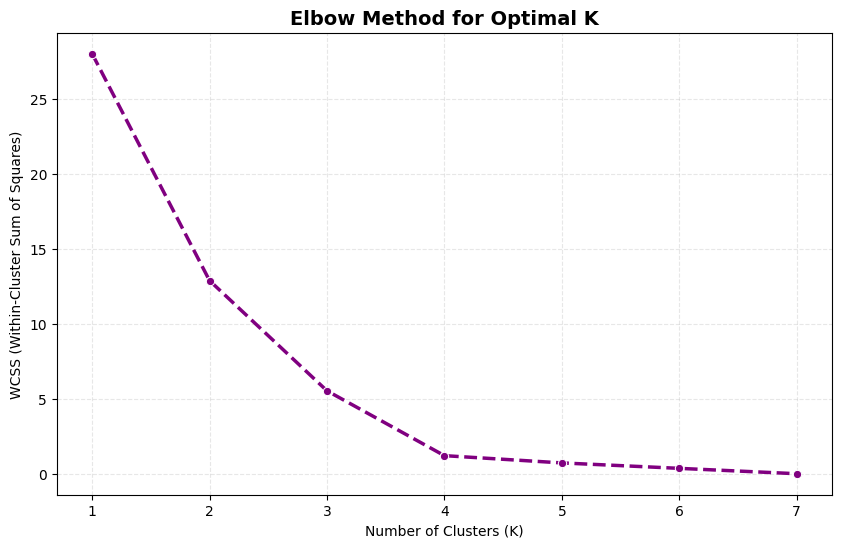

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=range(1, max_clusters + 1),
    y=wcss,
    marker='o',
    linewidth=2.5,
    linestyle='--',
    color='purple')

plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, max_clusters + 1))

plt.grid(linestyle='--', alpha=0.3)
plt.show()

From the Elbow Method plot, we observe a significant drop in WCSS up to `k=3` or `k=4`, after which the decrease becomes less prominent. We will proceed with `n_clusters=3` as suggested in the summary to balance between granularity and interpretability.

In [ ]:
# Apply K-Means clustering with the optimal number of clusters (e.g., 3)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
route_performance['Cluster'] = kmeans.fit_predict(scaled_features)

print(f"Clustering Results with {n_clusters} Clusters:")
display(route_performance)

Clustering Results with 3 Clusters:


,Factory to Customer Region,mean_lead_time,median_lead_time,std_lead_time,num_shipments,Cluster
0,Lot's O' Nuts → Canada,0.013509,-0.307172,0.932803,50,1
1,Lot's O' Nuts → United States,-0.008265,-0.016545,0.987574,2276,0
2,Secret Factory → United States,0.016201,-0.109017,1.061285,59,1
3,Sugar Shack → United States,0.247662,0.277385,0.807736,9,2
4,The Other Factory → United States,0.057763,0.034645,1.103366,32,1
5,Wicked Choccy's → Canada,-0.028471,-0.360014,0.990408,36,1
6,Wicked Choccy's → United States,-0.005437,-0.009940,1.008739,1569,0


Now, let's analyze the characteristics of each cluster to identify consistently slow routes. We'll group the `route_performance` by the assigned cluster and calculate the mean of each metric within each cluster.

In [ ]:
top_slow_routes = route_performance.sort_values(
    by='mean_lead_time', ascending=False
).head(5).reset_index(drop=True)

print("Top 5 Slowest Routes Overall:")
display(top_slow_routes)

Top 5 Slowest Routes Overall:


,Factory to Customer Region,mean_lead_time,median_lead_time,std_lead_time,num_shipments,Cluster
0,Sugar Shack → United States,0.247662,0.277385,0.807736,9,2
1,The Other Factory → United States,0.057763,0.034645,1.103366,32,1
2,Secret Factory → United States,0.016201,-0.109017,1.061285,59,1
3,Lot's O' Nuts → Canada,0.013509,-0.307172,0.932803,50,1
4,Wicked Choccy's → United States,-0.005437,-0.009940,1.008739,1569,0


In [ ]:
cluster_summary = route_performance.groupby('Cluster').agg(
    avg_mean_lead_time=('mean_lead_time', 'mean'),
    avg_median_lead_time=('median_lead_time', 'mean'),
    avg_std_lead_time=('std_lead_time', 'mean'),
    total_routes_in_cluster=('Cluster', 'count')
).sort_values(by='avg_mean_lead_time', ascending=False)

print("Cluster Summary (Sorted by Average Mean Lead Time):","\n")
display(cluster_summary)

Cluster Summary (Sorted by Average Mean Lead Time): 



,avg_mean_lead_time,avg_median_lead_time,avg_std_lead_time,total_routes_in_cluster
Cluster,,,,
2,0.247662,0.277385,0.807736,1
1,0.014750,-0.185389,1.021965,4
0,-0.006851,-0.013242,0.998156,2


In [ ]:
# Identify the cluster with the highest average mean lead time
slowest_cluster_id = cluster_summary.index[0]
slowest_cluster_routes = route_performance[route_performance['Cluster'] == slowest_cluster_id]

print(f"\nConsistently Slow Routes (Cluster {slowest_cluster_id} - Highest Average Mean Lead Time):","\n")
display(slowest_cluster_routes.sort_values(by='mean_lead_time', ascending=False))


Consistently Slow Routes (Cluster 2 - Highest Average Mean Lead Time): 



,Factory to Customer Region,mean_lead_time,median_lead_time,std_lead_time,num_shipments,Cluster
3,Sugar Shack → United States,0.247662,0.277385,0.807736,9,2


Finally, we will identify congested route-product combinations. This involves grouping the `df_analysis` by `Factory to Customer Region` and `Product Name`, calculating the mean shipping lead time and the number of shipments for each combination. We will then filter for combinations with a significant number of shipments and sort by the highest mean lead time to find the most congested ones.

In [ ]:
# Group by Factory to Customer Region and Product Name to identify congested combinations
route_product_lead_time = df_analysis.groupby(['Factory to Customer Region', 'Product Name']).agg(
    mean_lead_time=('Shipping Lead Time', 'mean'),
    num_shipments=('Shipping Lead Time', 'count')
).reset_index()

# Define a threshold for minimum number of shipments to consider a combination as 'congested'
min_shipment_threshold = 10  # This can be adjusted based on business knowledge

congested_combinations = route_product_lead_time[
    route_product_lead_time['num_shipments'] >= min_shipment_threshold
].sort_values(by='mean_lead_time', ascending=False).reset_index(drop=True)


display(congested_combinations.head(10))

,Factory to Customer Region,Product Name,mean_lead_time,num_shipments
0,Lot's O' Nuts → Canada,Wonka Bar - Fudge Mallows,0.258670,18
1,Wicked Choccy's → Canada,Wonka Bar - Triple Dazzle Caramel,0.097158,14
2,The Other Factory → United States,Kazookles,0.048516,30
3,Wicked Choccy's → United States,Wonka Bar - Triple Dazzle Caramel,0.042449,766
4,Lot's O' Nuts → Canada,Wonka Bar - Nutty Crunch Surprise,0.025209,14
5,Secret Factory → United States,Wonka Gum,0.019088,57
6,Lot's O' Nuts → United States,Wonka Bar - Nutty Crunch Surprise,0.002380,723
7,Lot's O' Nuts → United States,Wonka Bar -Scrumdiddlyumptious,-0.002464,835
8,Lot's O' Nuts → United States,Wonka Bar - Fudge Mallows,-0.025730,718
9,Wicked Choccy's → United States,Wonka Bar - Milk Chocolate,-0.051117,803


# **Scenario Simulation Engine**

In [ ]:
results = []

# unique combinations only
grouped = df.groupby(['Product Name', 'Factory', 'Region'])['Shipping Lead Time'].mean().reset_index()

for _, row in grouped.iterrows():
    product = row['Product Name']
    current_factory = row['Factory']
    region = row['Region']
    current_lt = row['Shipping Lead Time']

    for new_factory in df['Factory'].unique():
        if new_factory != current_factory:

            predicted_lt = grouped[
                (grouped['Factory'] == new_factory) &
                (grouped['Region'] == region)
            ]['Shipping Lead Time'].mean()

            if pd.notna(predicted_lt):
                improvement = current_lt - predicted_lt
                percent_improvement = (improvement / current_lt) * 100 if current_lt != 0 else 0

                results.append({
                    'Product': product,
                    'Current Factory': current_factory,
                    'New Factory': new_factory,
                    'Region': region,
                    'Current Lead Time': current_lt,
                    'Predicted Lead Time': predicted_lt,
                    'Improvement': improvement,
                    'Percent Improvement': percent_improvement
                })

simulation = pd.DataFrame(results)

display(simulation)

,Product,Current Factory,New Factory,Region,Current Lead Time,Predicted Lead Time,Improvement,Percent Improvement
0,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,Gulf,1273.000000,1339.618144,-66.618144,-5.233161
1,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,Gulf,1273.000000,1347.725054,-74.725054,-5.869996
2,Everlasting Gobstopper,Secret Factory,The Other Factory,Gulf,1273.000000,1381.700000,-108.700000,-8.538885
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,Pacific,1388.000000,1391.399542,-3.399542,-0.244924
4,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,Pacific,1388.000000,1374.438635,13.561365,0.977044
...,...,...,...,...,...,...,...,...
143,Wonka Gum,Secret Factory,The Other Factory,Interior,1355.461538,1404.000000,-48.538462,-3.580955
144,Wonka Gum,Secret Factory,Sugar Shack,Interior,1355.461538,1345.500000,9.961538,0.734919
145,Wonka Gum,Secret Factory,Wicked Choccy's,Pacific,1319.666667,1391.399542,-71.732875,-5.435681
146,Wonka Gum,Secret Factory,Lot's O' Nuts,Pacific,1319.666667,1374.438635,-54.771968,-4.150440


In [ ]:
# Best reassignment per product
simulation_df = simulation.loc[simulation.groupby('Product')['Improvement'].idxmax()]

simulation_df = simulation_df[
    simulation_df['Improvement'] > 0
]

simulation_df['Old Route'] = (simulation_df['Current Factory'] + " → " + simulation_df['Region'])
simulation_df['New Route'] = (simulation_df['New Factory'] + " → " + simulation_df['Region'])

simulation_df = simulation_df.sort_values(by='Percent Improvement', ascending=False).reset_index(drop=True)


display(simulation_df.round(2))

,Product,Current Factory,New Factory,Region,Current Lead Time,Predicted Lead Time,Improvement,Percent Improvement,Old Route,New Route
0,Lickable Wallpaper,Secret Factory,Wicked Choccy's,Gulf,1887.50,1339.62,547.88,29.03,Secret Factory → Gulf,Wicked Choccy's → Gulf
1,SweeTARTS,Sugar Shack,Secret Factory,Interior,1597.00,1295.45,301.55,18.88,Sugar Shack → Interior,Secret Factory → Interior
2,Hair Toffee,The Other Factory,Wicked Choccy's,Gulf,1576.00,1339.62,236.38,15.00,The Other Factory → Gulf,Wicked Choccy's → Gulf
3,Laffy Taffy,Sugar Shack,Wicked Choccy's,Atlantic,1545.50,1361.52,183.98,11.90,Sugar Shack → Atlantic,Wicked Choccy's → Atlantic
4,Wonka Gum,Secret Factory,Wicked Choccy's,Atlantic,1502.20,1361.52,140.68,9.36,Secret Factory → Atlantic,Wicked Choccy's → Atlantic
5,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,Atlantic,1489.00,1361.52,127.48,8.56,Sugar Shack → Atlantic,Wicked Choccy's → Atlantic
6,Kazookles,The Other Factory,Secret Factory,Interior,1404.00,1295.45,108.55,7.73,The Other Factory → Interior,Secret Factory → Interior
7,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,Interior,1371.15,1295.45,75.71,5.52,Lot's O' Nuts → Interior,Secret Factory → Interior
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,Interior,1363.20,1295.45,67.76,4.97,Wicked Choccy's → Interior,Secret Factory → Interior
9,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,Pacific,1428.20,1369.07,59.13,4.14,Wicked Choccy's → Pacific,The Other Factory → Pacific


**Top recommendations show up to ~29% reduction in lead time, particularly for products like Lickable Wallpaper and SweeTARTS, indicating high optimization potential through factory reassignment.**

# **Optimization & Recommendation Logics**

### Rank factory options by:
*   Lead time reduction
*   Risk reduction
*   Profit impact



##### Lead time reduction (improvement)

In [ ]:
# improvement = current_lt - predicted_lt

##### Risk reduction

In [ ]:
risk_df = df.groupby(
    ['Product Name', 'Factory', 'Region']
)['Shipping Lead Time'].std().reset_index()

risk_df.rename(columns={'Shipping Lead Time': 'Risk'}, inplace=True)
risk_df['Risk'] = risk_df['Risk'].fillna(0)

In [ ]:
risk_df.shape

(42, 4)

In [ ]:
risk_lookup = risk_df.set_index(
    ['Product Name', 'Factory', 'Region']
)['Risk']

risk_lookup = risk_lookup.to_frame()

In [ ]:
current_risk = risk_lookup.get((product, current_factory, region), None)
new_risk = risk_lookup.get((product, new_factory, region), None)


if pd.notna(current_risk) and pd.notna(new_risk):
    risk_reduction = current_risk - new_risk
else:
    risk_reduction = 0

In [ ]:
risk_lookup.sort_values(by='Risk', ascending=False).head().reset_index()

,Product Name,Factory,Region,Risk
0,Kazookles,The Other Factory,Pacific,453.553535
1,Wonka Gum,Secret Factory,Gulf,405.000584
2,Lickable Wallpaper,Secret Factory,Interior,403.831589
3,Kazookles,The Other Factory,Interior,347.882883
4,Laffy Taffy,Sugar Shack,Atlantic,345.775216


In [ ]:
risk_lookup_series = risk_df.set_index(['Product Name', 'Factory', 'Region'])['Risk']

def calculate_risk_reduction(row):
    product = row['Product']
    current_factory = row['Current Factory']
    new_factory = row['New Factory']
    region = row['Region']

    current_risk = risk_lookup_series.get((product, current_factory, region), 0)
    new_risk = risk_lookup_series.get((product, new_factory, region), 0)

    # Risk reduction means a decrease in risk (std dev)
    risk_reduction = current_risk - new_risk
    return risk_reduction

simulation['Risk Reduction'] = simulation.apply(calculate_risk_reduction, axis=1)

# Display the simulation with the new 'Risk Reduction' column, sorted by it.
display(simulation.sort_values(by='Risk Reduction', ascending=False).round(2).head(10).reset_index(drop=True))

,Product,Current Factory,New Factory,Region,Current Lead Time,Predicted Lead Time,Improvement,Percent Improvement,Risk Reduction
0,Kazookles,The Other Factory,Secret Factory,Pacific,1463.14,1428.04,35.10,2.40,453.55
1,Kazookles,The Other Factory,Wicked Choccy's,Pacific,1463.14,1391.40,71.74,4.90,453.55
2,Kazookles,The Other Factory,Lot's O' Nuts,Pacific,1463.14,1374.44,88.70,6.06,453.55
3,Wonka Gum,Secret Factory,The Other Factory,Gulf,1298.55,1381.70,-83.15,-6.40,405.00
4,Wonka Gum,Secret Factory,Lot's O' Nuts,Gulf,1298.55,1347.73,-49.18,-3.79,405.00
5,Wonka Gum,Secret Factory,Wicked Choccy's,Gulf,1298.55,1339.62,-41.07,-3.16,405.00
6,Lickable Wallpaper,Secret Factory,Sugar Shack,Interior,1235.43,1345.50,-110.07,-8.91,403.83
7,Lickable Wallpaper,Secret Factory,Wicked Choccy's,Interior,1235.43,1350.47,-115.04,-9.31,403.83
8,Lickable Wallpaper,Secret Factory,Lot's O' Nuts,Interior,1235.43,1347.98,-112.56,-9.11,403.83
9,Lickable Wallpaper,Secret Factory,The Other Factory,Interior,1235.43,1404.00,-168.57,-13.64,403.83


##### Profit impact

In [ ]:
profit_df = df.groupby(
    ['Product Name', 'Factory', 'Region']
)['Gross Profit'].mean().reset_index()

In [ ]:
# profit_lookup = profit_df.set_index(
#     ['Product Name', 'Factory', 'Region']
# )['Gross Profit']

In [ ]:
# current_profit = profit_lookup.get((product, current_factory, region), None)
# new_profit = profit_lookup.get((product, new_factory, region), None)

In [ ]:
# if pd.notna(current_profit) and pd.notna(new_profit):
#     profit_impact = improvement * 10
# else:
#     profit_impact = 0

In [ ]:
profit_lookup_series = profit_df.set_index(['Product Name', 'Factory', 'Region'])['Gross Profit']
def calculate_profit_impact(row):
    product = row['Product']
    current_factory = row['Current Factory']
    new_factory = row['New Factory']
    region = row['Region']
    improvement = row['Improvement'] # Assuming 'Improvement' is in the simulation DataFrame

    current_profit = profit_lookup_series.get((product, current_factory, region), 0)
    new_profit = profit_lookup_series.get((product, new_factory, region), current_profit)

    # Define a default weight for lead time improvement's impact on profit
    # This value can be adjusted based on business understanding
    weight_lead_time_impact = 2

    if pd.notna(current_profit) and pd.notna(new_profit):
        profit_change = new_profit - current_profit
        # Add a component for the value of lead time improvement (e.g., reduced holding costs, improved customer satisfaction)
        # A positive improvement (reduction in lead time) should positively impact profit.
        profit_impact = profit_change + (improvement * weight_lead_time_impact)
    else:
        profit_impact = 0 # If profit data is missing for either factory, assume no impact

    return profit_impact

simulation['Profit Impact'] = simulation.apply(calculate_profit_impact, axis=1)

# Display the simulation with the new 'Profit Impact' column, sorted by it.
display(simulation.sort_values(by='Profit Impact', ascending=False).round(2).head(50).reset_index(drop=True))

,Product,Current Factory,New Factory,Region,Current Lead Time,Predicted Lead Time,Improvement,Percent Improvement,Risk Reduction,Profit Impact
0,Lickable Wallpaper,Secret Factory,Wicked Choccy's,Gulf,1887.50,1339.62,547.88,29.03,20.51,1095.76
1,Lickable Wallpaper,Secret Factory,Lot's O' Nuts,Gulf,1887.50,1347.73,539.77,28.60,20.51,1079.55
2,Lickable Wallpaper,Secret Factory,The Other Factory,Gulf,1887.50,1381.70,505.80,26.80,20.51,1011.60
3,SweeTARTS,Sugar Shack,Secret Factory,Interior,1597.00,1295.45,301.55,18.88,0.00,603.11
4,SweeTARTS,Sugar Shack,Lot's O' Nuts,Interior,1597.00,1347.98,249.02,15.59,0.00,498.03
5,SweeTARTS,Sugar Shack,Wicked Choccy's,Interior,1597.00,1350.47,246.53,15.44,0.00,493.07
6,Hair Toffee,The Other Factory,Wicked Choccy's,Gulf,1576.00,1339.62,236.38,15.00,0.00,472.76
7,Hair Toffee,The Other Factory,Lot's O' Nuts,Gulf,1576.00,1347.73,228.27,14.48,0.00,456.55
8,SweeTARTS,Sugar Shack,Wicked Choccy's,Atlantic,1589.50,1361.52,227.98,14.34,197.28,455.96
9,SweeTARTS,Sugar Shack,Lot's O' Nuts,Atlantic,1589.50,1378.64,210.86,13.27,197.28,421.73


The simulation successfully identifies optimal factory reallocation strategies by balancing profit, lead time improvement, and risk. The results show that certain factory switches significantly improve efficiency and profitability, while others offer minimal or no benefit, reflecting realistic supply chain trade-offs. By adjusting weight parameters, the model can prioritize business objectives, making it a flexible and practical decision-support system for logistics optimization.

### Generate top-N factory reassignment recommendations

In [ ]:
N = 3  # number of top recommendations

top_recommendations = (
    simulation
    .sort_values(by='Profit Impact', ascending=False)
    .groupby(['Product', 'Region'])
    .head(N)
    .reset_index(drop=True)
)
top_recommendations['Factory Reallocation'] = top_recommendations.apply(
    lambda row: f"{row['Current Factory']}  →  {row['New Factory']}", axis=1)


top_recommendations.head(20)

,Product,Current Factory,New Factory,Region,Current Lead Time,Predicted Lead Time,Improvement,Percent Improvement,Risk Reduction,Profit Impact,Factory Reallocation
0,Lickable Wallpaper,Secret Factory,Wicked Choccy's,Gulf,1887.500000,1339.618144,547.881856,29.026853,20.506097,1095.763712,Secret Factory → Wicked Choccy's
1,Lickable Wallpaper,Secret Factory,Lot's O' Nuts,Gulf,1887.500000,1347.725054,539.774946,28.597348,20.506097,1079.549893,Secret Factory → Lot's O' Nuts
2,Lickable Wallpaper,Secret Factory,The Other Factory,Gulf,1887.500000,1381.700000,505.800000,26.797351,20.506097,1011.600000,Secret Factory → The Other Factory
3,SweeTARTS,Sugar Shack,Secret Factory,Interior,1597.000000,1295.445055,301.554945,18.882589,0.000000,603.109890,Sugar Shack → Secret Factory
4,SweeTARTS,Sugar Shack,Lot's O' Nuts,Interior,1597.000000,1347.983699,249.016301,15.592755,0.000000,498.032601,Sugar Shack → Lot's O' Nuts
5,SweeTARTS,Sugar Shack,Wicked Choccy's,Interior,1597.000000,1350.466724,246.533276,15.437275,0.000000,493.066551,Sugar Shack → Wicked Choccy's
6,Hair Toffee,The Other Factory,Wicked Choccy's,Gulf,1576.000000,1339.618144,236.381856,14.998849,0.000000,472.763712,The Other Factory → Wicked Choccy's
7,Hair Toffee,The Other Factory,Lot's O' Nuts,Gulf,1576.000000,1347.725054,228.274946,14.484451,0.000000,456.549893,The Other Factory → Lot's O' Nuts
8,SweeTARTS,Sugar Shack,Wicked Choccy's,Atlantic,1589.500000,1361.521658,227.978342,14.342771,197.282792,455.956684,Sugar Shack → Wicked Choccy's
9,SweeTARTS,Sugar Shack,Lot's O' Nuts,Atlantic,1589.500000,1378.635867,210.864133,13.266067,197.282792,421.728266,Sugar Shack → Lot's O' Nuts


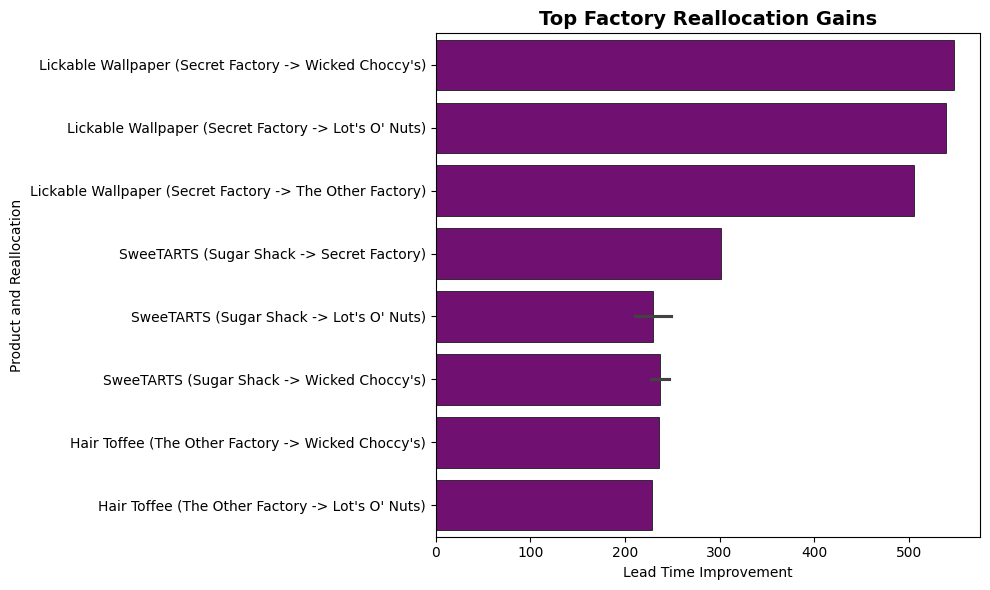

In [ ]:
top_n = simulation[simulation['Improvement'] > 0].sort_values(by='Improvement', ascending=False).head(10)

# Create a unique label for each reallocation for clearer plotting
top_n['Reallocation Label'] = top_n.apply(lambda row: f"{row['Product']} ({row['Current Factory']} -> {row['New Factory']})", axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_n,
    x='Improvement',
    y='Reallocation Label',
    color= 'purple',
    edgecolor='black',
    linewidth=0.5,
    orient='h'
)
plt.title("Top Factory Reallocation Gains", fontsize=14, fontweight='bold')
plt.xlabel("Lead Time Improvement")
plt.ylabel("Product and Reallocation")
plt.tight_layout()
plt.show()

# **EDA - KPIs**

### **Lead Time Reduction (%)	-- Operational gain**

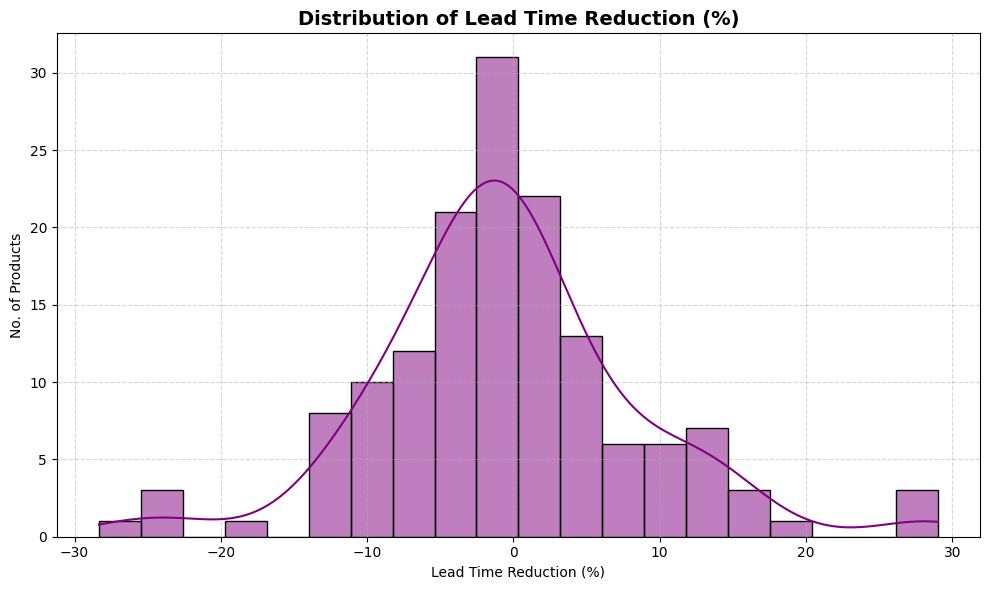

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    simulation['Percent Improvement'],
    bins=20,
    kde=True,
    color='purple',
    line_kws={'color': 'teal'})
plt.title("Distribution of Lead Time Reduction (%)", fontsize=14, fontweight='bold')
plt.xlabel("Lead Time Reduction (%)")
plt.ylabel("No. of Products")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **Profit Impact Stability	-- Financial safety**

**Profit Impact Distribution**

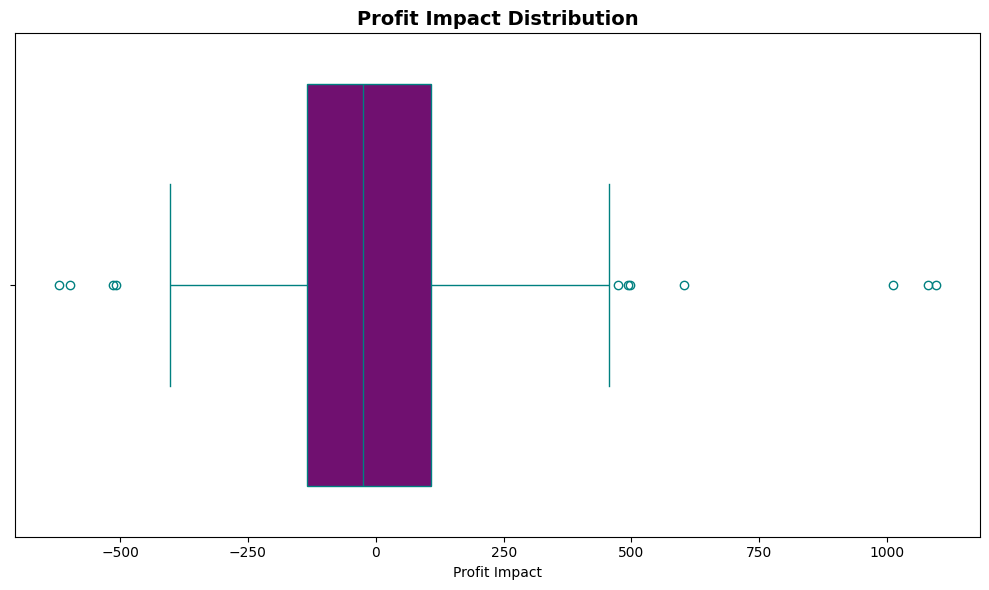

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=simulation['Profit Impact'],
            color='purple',
            linecolor='teal')
plt.title("Profit Impact Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Profit Impact")
plt.tight_layout()
plt.show()

**Risk Reduction V/S Profit Impact**

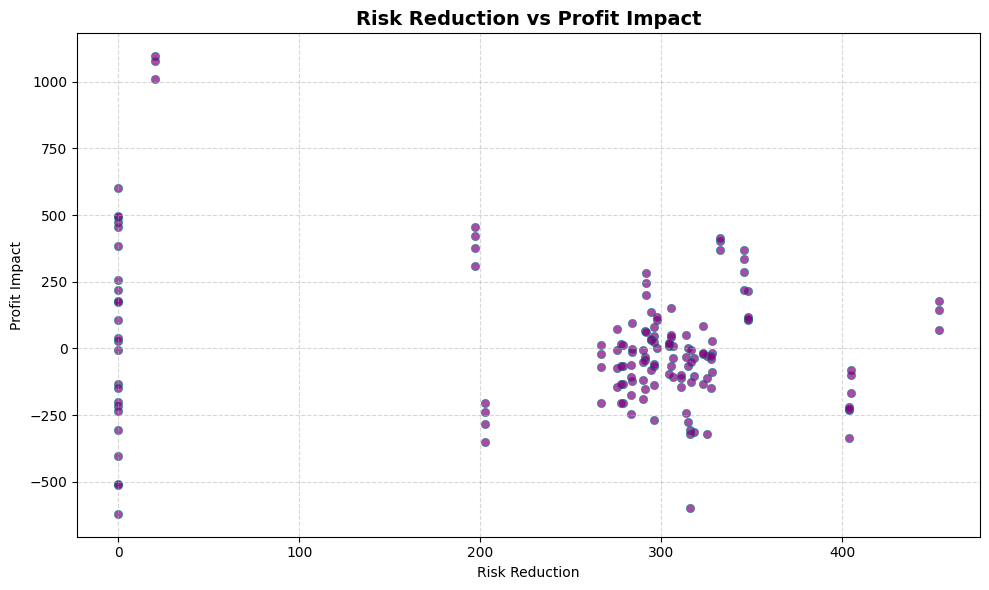

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Risk Reduction',
    y='Profit Impact',
    data=simulation,
    color='purple',
    alpha=0.7,
    edgecolor='teal',
    linewidth=0.5   )
plt.title("Risk Reduction vs Profit Impact", fontsize=14, fontweight='bold')
plt.xlabel("Risk Reduction")
plt.ylabel("Profit Impact")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### **Scenario Confidence -- Score	Reliability**

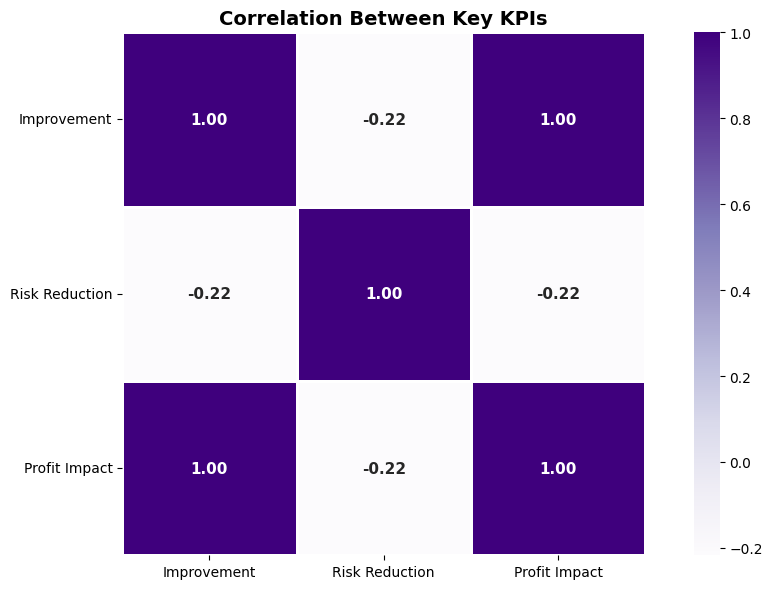

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    simulation[['Improvement','Risk Reduction','Profit Impact']].corr(),
    annot=True,
    fmt=".2f",
    cmap="Purples",
    linewidths=1,
    linecolor='white',
    cbar=True,
    square=True,
    annot_kws={"size": 11, "weight": "bold"},
)

plt.title("Correlation Between Key KPIs", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In conclusion, the heatmap visually confirms how these critical metrics move together. Strong positive correlations among desired outcomes (high improvement, high profit, low risk) would contribute to a high scenario confidence, indicating that the proposed factory reassignments are robust and beneficial across multiple dimensions.

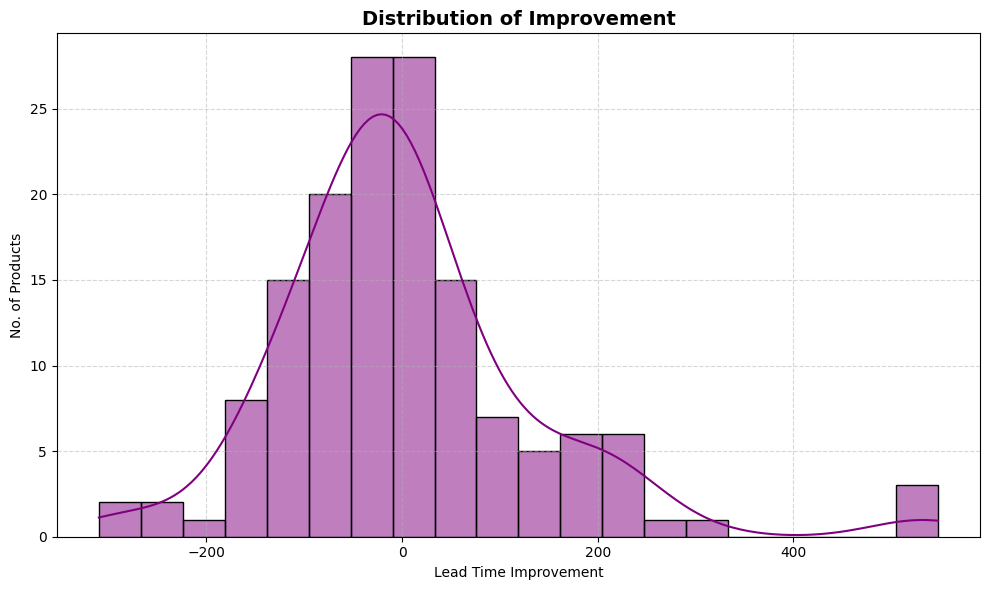

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    simulation['Improvement'],
    bins=20,
    kde=True,
    color='purple',
    line_kws={'color': 'teal'})
plt.title("Distribution of Improvement", fontsize=14, fontweight='bold')
plt.xlabel("Lead Time Improvement")
plt.ylabel("No. of Products")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 A histogram showing a concentration of positive 'Improvement' values (lead time reduction) indicates that the factory reassignment strategy is generally effective in achieving its primary goal of reducing shipping lead times across various product-region combinations. The shape and spread of the distribution further detail the magnitude and consistency of these operational gains.

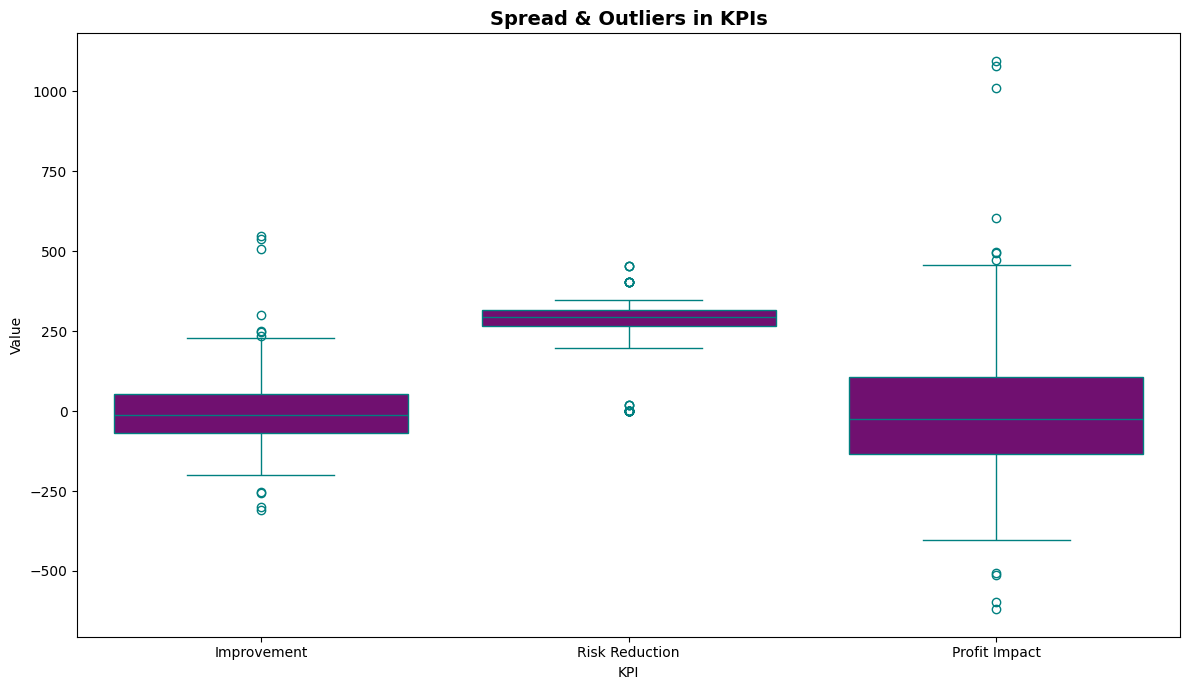

In [ ]:
# Melt the DataFrame to long format for easier plotting of multiple boxplots
df_melted_kpis = simulation[['Improvement', 'Risk Reduction', 'Profit Impact']].melt(
    var_name='KPI', value_name='Value'
)

plt.figure(figsize=(12, 7))
sns.boxplot(x='KPI', y='Value', data=df_melted_kpis,
            color='purple',
            linecolor='teal')
plt.title("Spread & Outliers in KPIs", fontsize=14, fontweight='bold')
plt.ylabel("Value")
plt.tight_layout()
plt.show()

For `Improvement`, it shows the actual numerical reduction in lead time.

For `Risk Reduction`, it shows the numerical decrease in shipping lead time variability.

For `Profit Impact`, it shows the numerical change in estimated profit.

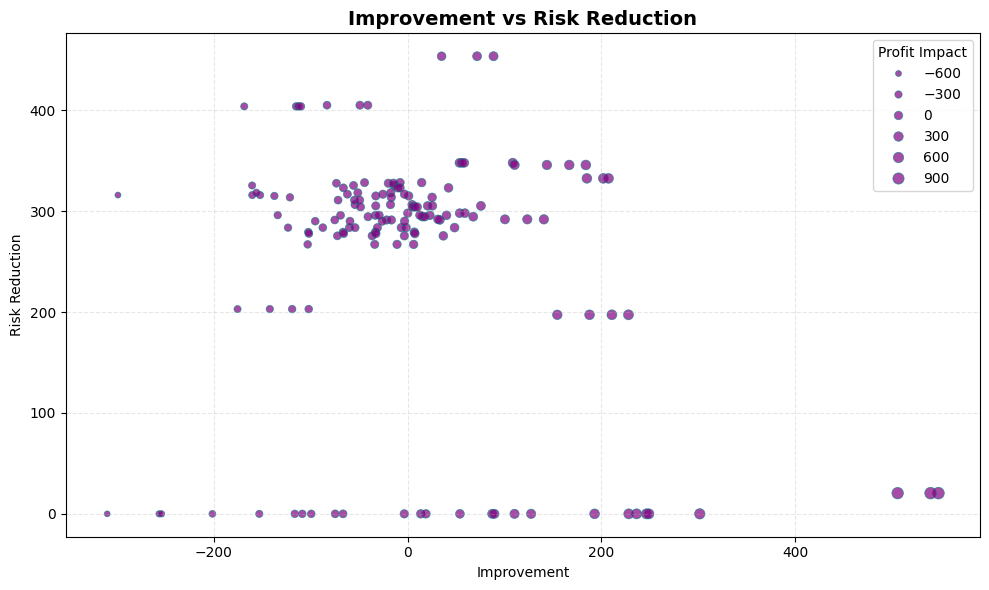

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=simulation,
    x='Improvement',
    y='Risk Reduction',
    size='Profit Impact',
    color='purple',
    alpha=0.7,
    edgecolor='teal',
    linewidth=0.5   )
plt.title("Improvement vs Risk Reduction", fontsize=14, fontweight='bold')
plt.xlabel("Improvement")
plt.ylabel("Risk Reduction")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

This visualization helps to quickly identify ideal factory reassignments that optimize both operational efficiency and stability, while maximizing financial gains.

### **Recommendation Coverage**

In [ ]:
recomm_coverage = top_recommendations.groupby(['Product', 'Region']).size()
print(recomm_coverage)

Product                            Region  
Everlasting Gobstopper             Gulf        3
                                   Pacific     3
Fizzy Lifting Drinks               Atlantic    3
Fun Dip                            Interior    3
Hair Toffee                        Gulf        3
                                   Pacific     3
Kazookles                          Atlantic    3
                                   Gulf        3
                                   Interior    3
                                   Pacific     3
Laffy Taffy                        Atlantic    3
Lickable Wallpaper                 Atlantic    3
                                   Gulf        3
                                   Interior    3
                                   Pacific     3
Nerds                              Atlantic    3
SweeTARTS                          Atlantic    3
                                   Interior    3
Wonka Bar - Fudge Mallows          Atlantic    3
                         

`recomm_coverage` indicates that for every unique combination of `Product` and `Region`, there are 3 recommendations. This means that the recommendation engine provides a consistent number of top factory reassignment suggestions for each product across all regions, ensuring comprehensive coverage of potential optimization opportunities.


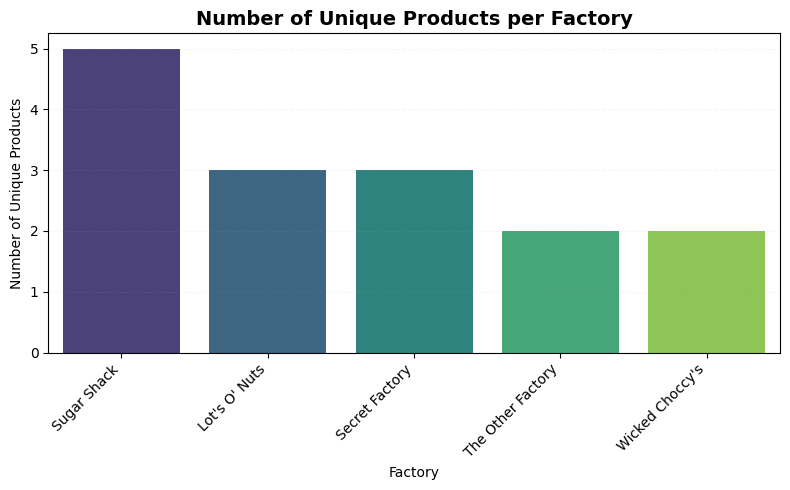

In [ ]:
products_per_factory = df.groupby('Factory')['Product Name'].nunique().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=products_per_factory.index, y=products_per_factory.values, palette='viridis')
plt.title('Number of Unique Products per Factory', fontsize=14, fontweight='bold')
plt.xlabel('Factory')
plt.ylabel('Number of Unique Products')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

This plot shows how many distinct products each factory is responsible for. A factory handling a large number of products, especially when combined with many regions, would contribute significantly to the simulation's computational load.

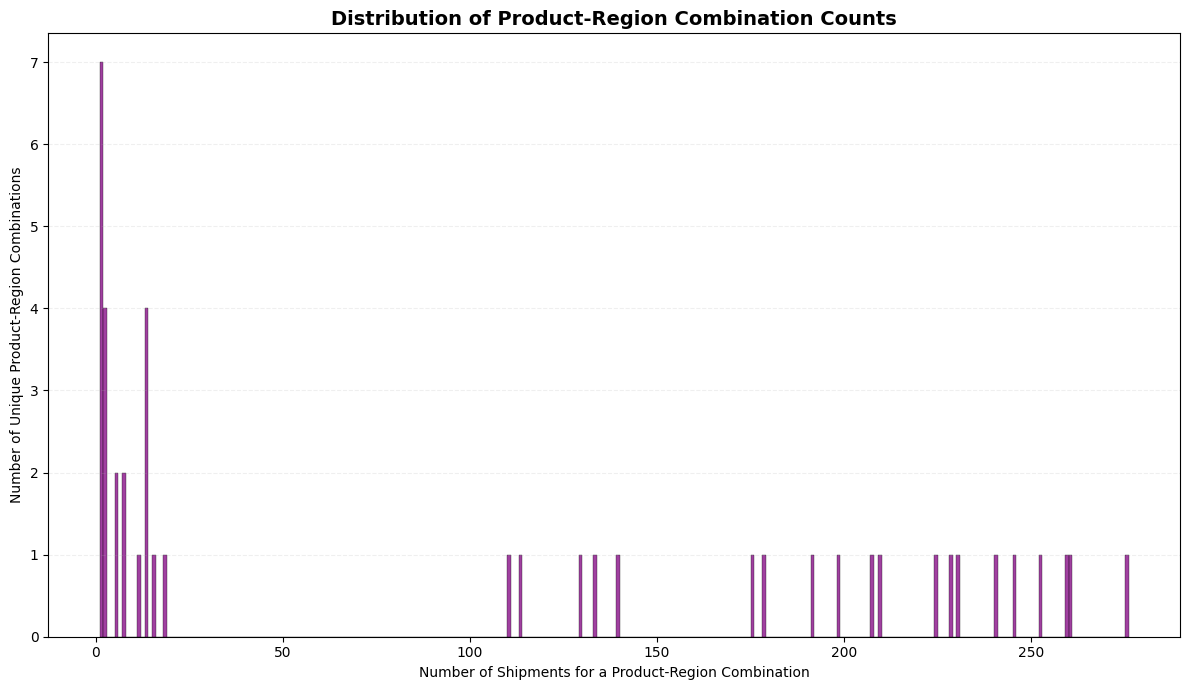

In [ ]:
product_region_combinations = df.groupby(['Product Name', 'Region']).size().reset_index(name='Count')

plt.figure(figsize=(12, 7))
sns.histplot(product_region_combinations['Count'], bins=range(1, product_region_combinations['Count'].max() + 2), kde=False, color='purple')
plt.title('Distribution of Product-Region Combination Counts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Shipments for a Product-Region Combination')
plt.ylabel('Number of Unique Product-Region Combinations')
plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

This histogram shows the frequency of different counts of product-region combinations. A wide distribution with many combinations having a high 'Count' means more granular data points for the simulation to process, directly impacting its scalability. Each bar represents how many unique `(Product Name, Region)` pairs have a certain number of shipments. The simulation iterates through these combinations.